# <font color='darkred'>**TMBD Movies**</font>

## **Table of Contents**
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## **Introduction**

> This dataset comes from IMDB and contains information about 10,000 movies,
short films and tv series collected from The Movie Database (TMDb), including user ratings, revenue, runtime and budget.

## **Generate Questions**

In this project, i'll be answering the following questions:
- What's the genre with the highest median popularity?
- What's the genre with the highest median revenue?
- What's the genre with the highest median vote_count?
- What's the genre with the highest mean vote_average?
- what movie is considered movie genre is considered the "best"?
- What month is considered "best" for releasing a films?
- What is the relationship between the columns and each other?

## **Import Libraries**

## **Data Wrangling**


### General Properties

In [73]:
# Load your data and print out a few lines. Perform operations to inspect data
#   types and look for instances of missing or possibly errant data.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [74]:
file_path = '../tmdb-movies.csv'
imdb = pd.read_csv(file_path)

In [75]:
imdb.head(10)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09
5,281957,tt1663202,9.110700,135000000,532950503,The Revenant,Leonardo DiCaprio|Tom Hardy|Will Poulter|Domhn...,http://www.foxmovies.com/movies/the-revenant,Alejandro GonzÃ¡lez IÃ±Ã¡rritu,"(n. One who has returned, as if from the dead.)",...,"In the 1820s, a frontiersman, Hugh Glass, sets...",156,Western|Drama|Adventure|Thriller,Regency Enterprises|Appian Way|CatchPlay|Anony...,12/25/15,3929,7.2,2015,1.241999e+08,4.903142e+08
6,87101,tt1340138,8.654359,155000000,440603537,Terminator Genisys,Arnold Schwarzenegger|Jason Clarke|Emilia Clar...,http://www.terminatormovie.com/,Alan Taylor,Reset the future,...,"The year is 2029. John Connor, leader of the r...",125,Science Fiction|Action|Thriller|Adventure,Paramount Pictures|Skydance Productions,6/23/15,2598,5.8,2015,1.425999e+08,4.053551e+08
7,286217,tt3659388,7.667400,108000000,595380321,The Martian,Matt Damon|Jessica Chastain|Kristen Wiig|Jeff ...,http://www.foxmovies.com/movies/the-martian,Ridley Scott,Bring Him Home,...,"During a manned mission to Mars, Astronaut Mar...",141,Drama|Adventure|Science Fiction,Twentieth Century Fox Film Corporation|Scott F...,9/30/15,4572,7.6,2015,9.935996e+07,5.477497e+08
8,211672,tt2293640,7.404165,74000000,1156730962,Minions,Sandra Bullock|Jon Hamm|Michael Keaton|Allison...,http://www.minionsmovie.com/,Kyle Balda|Pierre Coffin,"Before Gru, they had a history of bad bosses",...,"Minions Stuart, Kevin and Bob are recruited by...",91,Family|Animation|Adventure|Comedy,Universal Pictures|Illumination Entertainment,6/17/15,2893,6.5,2015,6.807997e+07,1.064192e+09
9,150540,tt2096673,6.326804,175000000,853708609,Inside Out,Amy Poehler|Phyllis Smith|Richard Kind|Bill Ha...,http://movies.disney.com/inside-out,Pete Docter,Meet the little voices inside your head.,...,"Growing up can be a bumpy road, and it's no ex...",94,Comedy|Animation|Family,Walt Disney Pictures|Pixar Animation Studios|W...,6/9/15

In [76]:
print(imdb.shape)
print(imdb.info())


(10866, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release

In [77]:
# Does it contain any missing data?
imdb.isnull().values.any()

True

In [78]:
# Check for missing values in each column

missing_values_count = imdb.isnull().sum()
# Display the result

missing_values_count = missing_values_count[missing_values_count > 0]


print(missing_values_count)

imdb_id                   10
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
genres                    23
production_companies    1030
dtype: int64


In [79]:
# Percentage of missing data in each column
missing_percentage = (imdb.isnull().sum() / len(imdb)) * 100

# Filter to show only columns with more than 0% missing data
missing_percentage = missing_percentage[missing_percentage > 0]

# Display the result
print(missing_percentage)

imdb_id                  0.092030
cast                     0.699429
homepage                72.979937
director                 0.404933
tagline                 25.989324
keywords                13.740107
overview                 0.036812
genres                   0.211669
production_companies     9.479109
dtype: float64


## **Data Cleaning**

Any missing data: True

Missing values count per column:
imdb_id                   10
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
genres                    23
production_companies    1030
dtype: int64

Percentage of missing data per column:
imdb_id                  0.092030
cast                     0.699429
homepage                72.979937
director                 0.404933
tagline                 25.989324
keywords                13.740107
overview                 0.036812
genres                   0.211669
production_companies     9.479109
dtype: float64


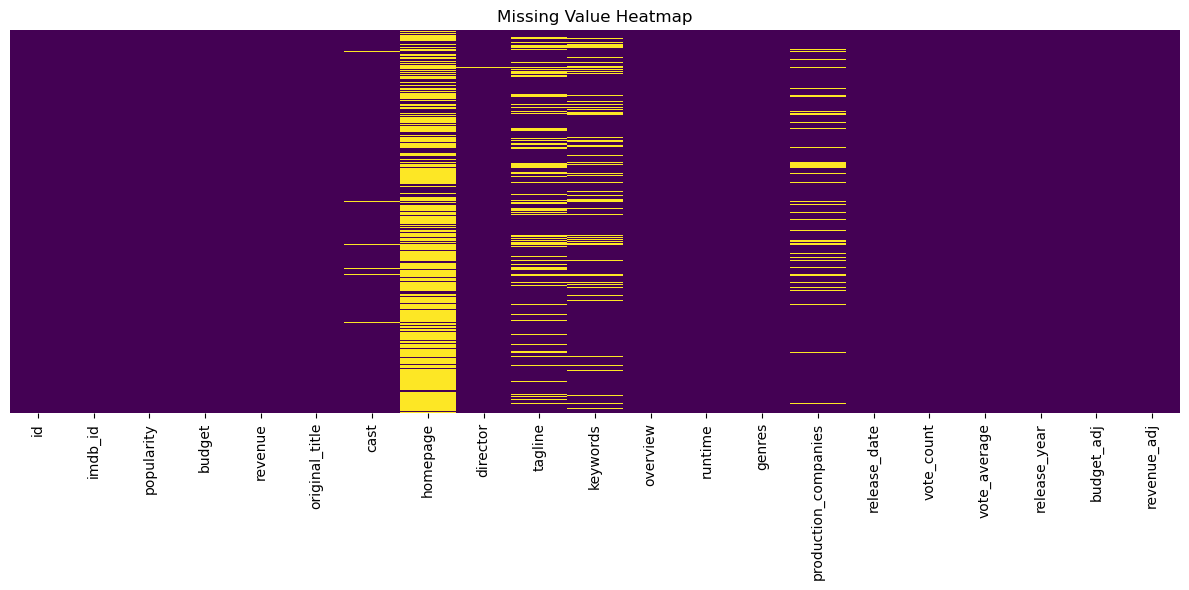

In [80]:
# create a function to find and display NAs

def check_missing_data(df):
    """
    Check for missing data in a DataFrame and summarize the results.
    
    Parameters:
    df (DataFrame): The DataFrame to check for missing data.
    
    Returns:
    None: Prints the results to the console.
    """
    # Check if there's any missing data in the entire DataFrame
    any_missing = df.isnull().values.any()
    print(f"Any missing data: {any_missing}")
    
    # Count and print the number of missing values per column (only those with missing values)
    missing_values_count = df.isnull().sum()
    missing_values_count = missing_values_count[missing_values_count > 0]
    print("\nMissing values count per column:")
    print(missing_values_count)
    
    # Calculate and print the percentage of missing data per column (only those with missing percentages)
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    missing_percentage = missing_percentage[missing_percentage > 0]
    print("\nPercentage of missing data per column:")
    print(missing_percentage)

    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
    plt.title('Missing Value Heatmap')
    plt.tight_layout()
    plt.show()

# Now you can use this function on your DataFrame like this:
check_missing_data(imdb)

In [81]:
# Function to clean a dataframe
def cleaning(df):
    """
    Cleans the DataFrame by standardizing column names, removing fully empty rows, and dropping duplicates.
    
    Parameters:
    df (DataFrame): The DataFrame to clean.

    Returns:
    DataFrame: The cleaned DataFrame.
    """

    # Store the initial number of rows
    initial_row_count = len(df)

    # Standardize column names
    df.columns.map(lambda col: col.lower())
    df.columns = df.columns.str.lower().str.replace(' ', '_')

    # Drop rows where all values are NA and report the count
    df = df.dropna(how="all")
    rows_after_dropping_na = len(df)
    print(f"Dropped {initial_row_count - rows_after_dropping_na} rows with all NAs.")

    # Drop duplicate rows and report the count
    df = df.drop_duplicates()
    final_row_count = len(df)
    print(f"Dropped {rows_after_dropping_na - final_row_count} duplicate rows.")

    # Return the cleaned DataFrame
    return df

cleaned_imdb = cleaning(imdb)

Dropped 0 rows with all NAs.
Dropped 1 duplicate rows.


In [82]:
print(cleaned_imdb.head())


       id    imdb_id  popularity     budget     revenue  \
0  135397  tt0369610   32.985763  150000000  1513528810   
1   76341  tt1392190   28.419936  150000000   378436354   
2  262500  tt2908446   13.112507  110000000   295238201   
3  140607  tt2488496   11.173104  200000000  2068178225   
4  168259  tt2820852    9.335014  190000000  1506249360   

                 original_title  \
0                Jurassic World   
1            Mad Max: Fury Road   
2                     Insurgent   
3  Star Wars: The Force Awakens   
4                     Furious 7   

                                                cast  \
0  Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...   
1  Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...   
2  Shailene Woodley|Theo James|Kate Winslet|Ansel...   
3  Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...   
4  Vin Diesel|Paul Walker|Jason Statham|Michelle ...   

                                            homepage          director  \
0                      

<a id='eda'></a>
## **Exploratory Data Analysis**

### What's the genre with the highest median popularity?

In [83]:
cleaned_imdb.columns

Index(['id', 'imdb_id', 'popularity', 'budget', 'revenue', 'original_title',
       'cast', 'homepage', 'director', 'tagline', 'keywords', 'overview',
       'runtime', 'genres', 'production_companies', 'release_date',
       'vote_count', 'vote_average', 'release_year', 'budget_adj',
       'revenue_adj'],
      dtype='object')

In [84]:
# cleaned_imdb.groupby('genres').median()
# it does not work

# Step 2: Split the genres
# Your genres might be in a format like 'Action|Adventure', you'd split on '|'
cleaned_imdb['split_genres'] = cleaned_imdb['genres'].str.split('|')
# Step 3: Explode the genres into separate rows
exploded_df = cleaned_imdb.explode('split_genres')

exploded_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26978 entries, 0 to 10865
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    26978 non-null  int64  
 1   imdb_id               26953 non-null  object 
 2   popularity            26978 non-null  float64
 3   budget                26978 non-null  int64  
 4   revenue               26978 non-null  int64  
 5   original_title        26978 non-null  object 
 6   cast                  26853 non-null  object 
 7   homepage              7155 non-null   object 
 8   director              26885 non-null  object 
 9   tagline               20584 non-null  object 
 10  keywords              23639 non-null  object 
 11  overview              26972 non-null  object 
 12  runtime               26978 non-null  int64  
 13  genres                26955 non-null  object 
 14  production_companies  24766 non-null  object 
 15  release_date          26

In [85]:
exploded_df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,26978.000000,26978.000000,2.697800e+04,2.697800e+04,26978.000000,26978.000000,26978.000000,26978.000000,2.697800e+04,2.697800e+04
mean,58765.839425,0.705653,1.749289e+07,4.740320e+07,102.773000,249.801579,5.956932,2000.701794,2.102152e+07,6.083795e+07
std,86797.833418,1.114621,3.459795e+07,1.321609e+08,30.411297,637.784544,0.912318,12.764426,3.818896e+07,1.614714e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10202.000000,0.224439,0.000000e+00,0.000000e+00,90.000000,18.000000,5.400000,1994.000000,0.000000e+00,0.000000e+00
50%,18220.000000,0.410850,9.300000e+01,0.000000e+00,99.000000,44.000000,6.000000,2005.000000,1.039001e+02,0.000000e+00
75%,58432.000000,0.774231,2.000000e+07,3.052607e+07,112.000000,173.000000,6.600000,2011.000000,2.704173e+07,4.359754e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


In [86]:
genre_median_popularity = exploded_df.groupby('split_genres')['popularity'].median()
genre_median_popularity

split_genres
Action             0.469825
Adventure          0.561034
Animation          0.501163
Comedy             0.388667
Crime              0.476338
Documentary        0.142240
Drama              0.389212
Family             0.470249
Fantasy            0.530123
Foreign            0.165482
History            0.412770
Horror             0.321891
Music              0.321763
Mystery            0.428021
Romance            0.403937
Science Fiction    0.439600
TV Movie           0.230561
Thriller           0.444337
War                0.432470
Western            0.328263
Name: popularity, dtype: float64

In [87]:
highest_median_genre = genre_median_popularity.idxmax()
highest_median_value = round(genre_median_popularity.max(), 2)
print(f"The genre with the highest median popularity is: {highest_median_genre} with a median popularity of {highest_median_value}")

The genre with the highest median popularity is: Adventure with a median popularity of 0.56


### What's the genre with the highest median revenue?

In [88]:
genre_median_revenue = exploded_df.groupby('split_genres')['revenue'].median()
highest_median_revenue = genre_median_revenue.idxmax()
highest_median_rev_value = int(genre_median_revenue.max())

print(f"The genre with the highest median revenue is: {highest_median_revenue} with a median revenue of U$D{highest_median_rev_value: ,}")

The genre with the highest median revenue is: Adventure with a median revenue of U$D 9,697,739


### What's the genre with the highest median vote_count?

In [89]:
genre_median_vote_c = exploded_df.groupby('split_genres')['vote_count'].median()
genre_median_vote_c
# highest_median_vote_c = genre_median_vote_c

split_genres
Action             54.0
Adventure          90.0
Animation          56.0
Comedy             42.0
Crime              63.0
Documentary        19.0
Drama              37.0
Family             49.0
Fantasy            68.0
Foreign            13.0
History            41.0
Horror             30.0
Music              33.0
Mystery            48.5
Romance            41.5
Science Fiction    52.0
TV Movie           20.0
Thriller           50.0
War                43.5
Western            27.0
Name: vote_count, dtype: float64

In [90]:
highest_median_vote_c = genre_median_vote_c.idxmax()
highest_median_vote_c_v = genre_median_vote_c.max()

print(f"The genre with the highest median vote count is: {highest_median_vote_c} with a median vote count of {highest_median_vote_c_v}")

The genre with the highest median vote count is: Adventure with a median vote count of 90.0


### What's the genre with the highest mean vote_average?

In [91]:
genre_mean_vote_a = exploded_df.groupby('split_genres')['vote_average'].mean().sort_values(ascending=False)
genre_mean_vote_a

split_genres
Documentary        6.908462
Music              6.480392
History            6.410479
Animation          6.403147
War                6.297778
Drama              6.165546
Crime              6.124889
Western            6.083030
Romance            6.042874
Family             5.997563
Foreign            5.981383
Mystery            5.946790
Adventure          5.940585
Comedy             5.905167
Fantasy            5.863537
TV Movie           5.788024
Action             5.787752
Thriller           5.750671
Science Fiction    5.665582
Horror             5.337447
Name: vote_average, dtype: float64

In [92]:
highest_mean_v_a = genre_mean_vote_a.idxmax()
highest_mean_v_a_v = round(genre_mean_vote_a.max(), 2)
print(f"The genre with the highest mean vote average is: {highest_mean_v_a} with a median vote count of {highest_mean_v_a_v}")

The genre with the highest mean vote average is: Documentary with a median vote count of 6.91


### What movie is considered movie genre is considered the "best"?


In [93]:
cleaned_imdb['norm_revenue'] = cleaned_imdb['revenue'] / cleaned_imdb['revenue'].max()
cleaned_imdb['norm_popularity'] = cleaned_imdb['popularity'] / cleaned_imdb['popularity'].max()

# Combine them (equal weighting)
cleaned_imdb['composite_score'] = (cleaned_imdb['norm_revenue'] + cleaned_imdb['norm_popularity']) / 2

# Split and explode genres (as you did before)
exploded_df = cleaned_imdb.explode('split_genres')

# Group by genre and calculate median composite score
best_genre = exploded_df.groupby('split_genres')['composite_score'].median().idxmax()

print(f"The 'best' genre is: {best_genre}")

The 'best' genre is: Adventure


### What month is considered "best" for releasing a films/shows?


In [94]:
# cleaned_imdb['release_month'] = pd.to_datetime(cleaned_imdb['release_date']).dt.month

cleaned_imdb['release_month'] = pd.to_datetime(
    cleaned_imdb['release_date'], 
    format='%m/%d/%y'  # <-- Corrected format for two-digit year
).dt.month
cleaned_imdb['release_month']

0         6
1         5
2         3
3        12
4         4
         ..
10861     6
10862    12
10863     1
10864    11
10865    11
Name: release_month, Length: 10865, dtype: int32

In [97]:
# Filter out movies with revenue <= 0  
valid_revenue_df = cleaned_imdb[cleaned_imdb['revenue'] > 0]  

# Now re-calculate monthly stats  
monthly_stats = valid_revenue_df.groupby('release_month')['revenue'].median().reset_index()
monthly_stats

,release_month,revenue
0,1,17505772.5
1,2,29300000.0
2,3,32709423.0
3,4,28831145.0
4,5,27737543.0
5,6,61156330.0
6,7,50443455.0
7,8,26673242.0
8,9,13368437.0
9,10,22864316.0


In [96]:
print(f"Total movies: {len(cleaned_imdb)}")  
print(f"Movies with revenue > 0: {len(valid_revenue_df)}")  

Total movies: 10865
Movies with revenue > 0: 4849


In [98]:
# Sort descending to see top months  
best_month = monthly_stats.sort_values('revenue', ascending=False).iloc[0]  
print(f"Best month: {best_month['release_month']} (Median Revenue: ${best_month['revenue']:,.0f})")  

Best month: 6.0 (Median Revenue: $61,156,330)


<a id='conclusions'></a>
## Conclusions


## Limitations


---
### **1. Conclusions**  
**Key Findings**:  
- **Genre Analysis**:  
  - **Adventure** dominates as the "best" genre across most metrics:  
    - Highest median popularity (0.56)  
    - Highest median revenue ($9.7M)  
    - Highest median vote count (90)  
    - Top composite score (revenue + popularity)  
  - **Documentaries** have the highest mean vote average (6.91), suggesting strong audience approval despite lower commercial metrics.  

- **Release Timing**:  
  - June (**Month 6**) is the optimal release month for maximizing median revenue ($61.16M), likely tied to summer blockbuster seasons.  

**Takeaway**:  
The definition of "best" depends on the metric. Adventure is the most commercially successful genre, while documentaries excel in audience ratings.



---

### **2. Limitations**  
1. **Data Quality**:  
   - Many movies had $0 revenue, requiring filtering. This may exclude niche or poorly tracked films.  
   - Genres are non-exclusive (e.g., "Action|Adventure"), potentially inflating Adventure’s dominance.  

2. **Metric Limitations**:  
   - **Median vs. Mean**: Medians ignore outliers (e.g., mega-blockbusters), while means can be skewed by extreme values.  
   - **Composite Score Subjectivity**: Equal weighting of revenue/popularity is arbitrary. Different weights could change results.  

3. **Temporal Bias**:  
   - Data may reflect historical trends (e.g., past popularity of Adventure films) rather than current preferences.  

4. **Revenue Context**:  
   - Revenue figures are not adjusted for inflation unless `revenue_adj` was used.  

---

### **Suggested Improvements**  
- Explore genre overlaps (e.g., "Action-Adventure" partnerships).  
- Compare adjusted revenue (`revenue_adj`) for fairer year-to-year comparisons.  
- Test alternative "best" definitions (e.g., profitability = revenue - budget). 